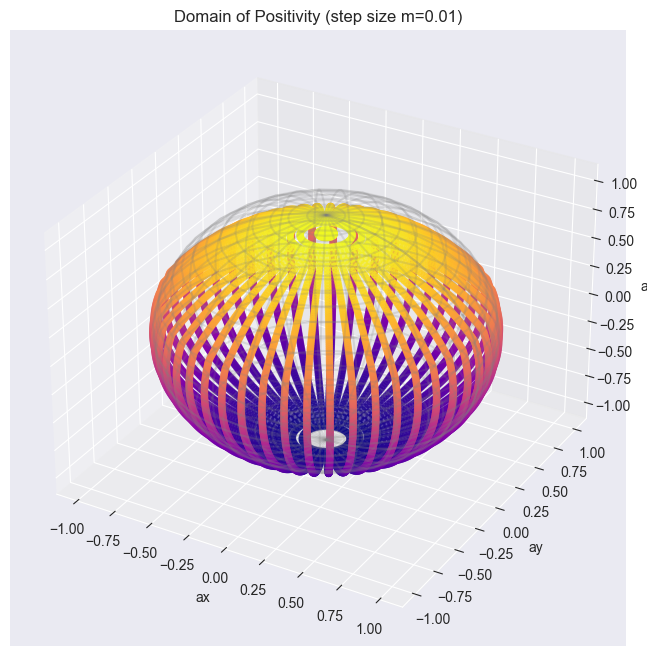

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def parametric_domain(l1, l3, t3):
    """
    Returns the parametric form of the domain of positivity.

    Parameters:
    l1, l3, t3: map parameters

    Returns:
    function r(az) that gives the radius at height az
    """
    def radius_function(az):
        """
        For given az, return the maximum radius in xy-plane
        r(az) = min(√(1-az²), √((1-(t3+l3*az)²)/l1²))
        """
        # Constraint 1: Bloch sphere
        r1_sq = 1 - az**2

        # Constraint 2: Output constraint
        r2_sq = (1 - (t3 + l3*az)**2) / l1**2

        #because ax^2 + ay^2 cannot be negative, we take the minimum of the two constraints
        if r1_sq < 0 or r2_sq < 0:
            return 0

        return np.sqrt(min(r1_sq, r2_sq))

    return radius_function

def plot_domain_on_bloch(radius_function, m=0.1):
    """
    Plot the parametric domain on Bloch sphere

    Parameters:
    radius_function: function r(az) from parametric_domain()
    m: step size for az sampling
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Generate az values with step size m
    az_vals = np.arange(-1, 1 + m, m)

    domain_points = []

    for az in az_vals:
        r_max = radius_function(az)

        if r_max > 1e-10:  # Only plot if radius is meaningful
            # Generate circle at this az level
            theta_vals = np.linspace(0, 2*np.pi, 50)
            for theta in theta_vals:
                ax_coord = r_max * np.cos(theta)
                ay_coord = r_max * np.sin(theta)
                domain_points.append([ax_coord, ay_coord, az])

    # Plot domain points
    if domain_points:
        domain_points = np.array(domain_points)
        ax.scatter(domain_points[:, 0], domain_points[:, 1], domain_points[:, 2],
                  c=domain_points[:, 2], cmap='plasma', alpha=0.7, s=20)

    # Plot reference Bloch sphere
    u = np.linspace(0, 2*np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, alpha=0.2, color='gray')

    ax.set_xlabel('ax')
    ax.set_ylabel('ay')
    ax.set_zlabel('az')
    ax.set_title(f'Domain of Positivity (step size m={m})')

    plt.show()